In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import libpysal.weights as weights
import esda

# Configuración de visualización
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.precision', 3)

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cargar imagen Sentinel-2 del Dique Roggero
# Usaremos la imagen de octubre 2018 (antes del cambio)
raster_path = r"C:\Users\USUARIO\Documents\UNSAM\Analisis de Datos Espaciales\Notebooks\data\raw_data\SPOT_20170806_MS_p.tif"

with rasterio.open(raster_path) as src:
    # Leer todas las bandas
    img = src.read()
    img = img[:,200:800,750:1500]
    transform = src.transform
    crs = src.crs
    
    # Bandas Sentinel-2: 1=B, 2=G, 3=R, 4=NIR
    # Calcular NDVI: (NIR - R) / (NIR + R)
    nir = img[3].astype(float)  # Banda 4 = NIR
    red = img[2].astype(float)  # Banda 3 = R
    ndvi = (nir - red) / (nir + red + 1e-10)
    
    # Obtener máscara de nodata y valores válidos
    ndvi_valid = ndvi[(ndvi > -1) & (ndvi < 1)]
    

print(f"Dimensiones del raster NDVI: {ndvi.shape}")
print(f"Rango NDVI: [{ndvi_valid.min():.3f}, {ndvi_valid.max():.3f}]")
print(f"NDVI promedio: {ndvi_valid.mean():.3f}")
print(f"CRS: {crs}") 

Dimensiones del raster NDVI: (600, 750)
Rango NDVI: [-0.356, 0.652]
NDVI promedio: 0.146
CRS: EPSG:32720


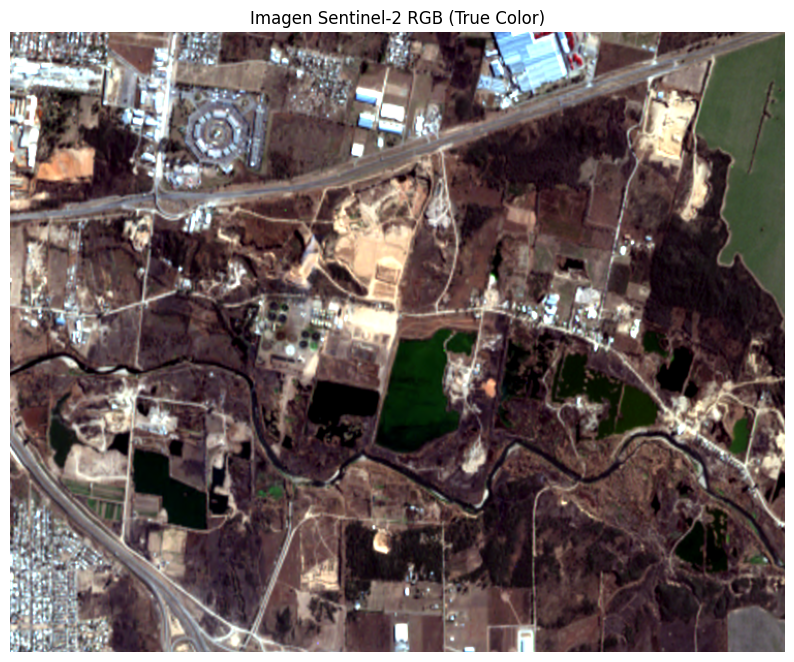

In [3]:
# Seleccionar bandas en orden RGB (3 bandas)
R = img[2].astype(float)
G = img[1].astype(float)
B = img[0].astype(float)

# Normalización rápida a 0–1
def normalize(band):
    band_min, band_max = np.percentile(band, (2, 98))  # estirado pequeño
    return np.clip((band - band_min) / (band_max - band_min), 0, 1)

R_n = normalize(R)
G_n = normalize(G)
B_n = normalize(B)

rgb = np.dstack([R_n, G_n, B_n])

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Imagen Sentinel-2 RGB (True Color)")
plt.axis("off")
plt.show()

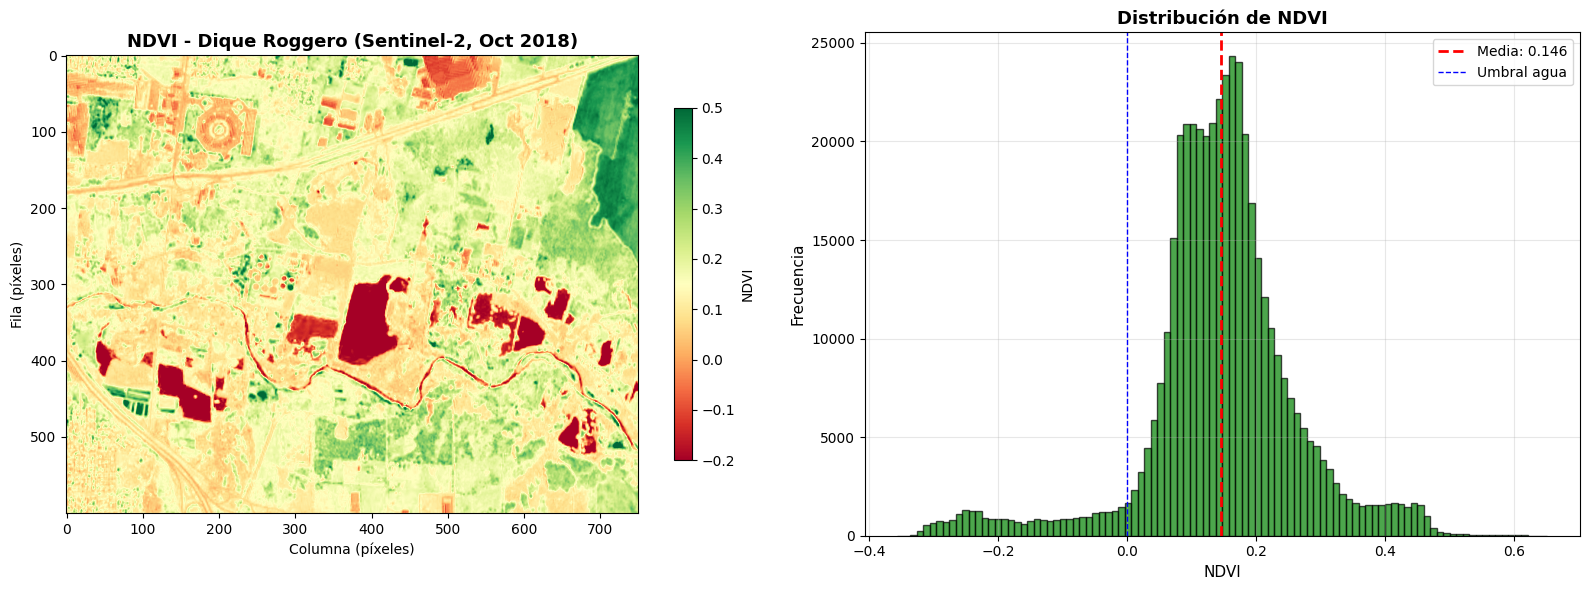

In [4]:
# Visualizar el NDVI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mapa de NDVI
im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.5)
ax1.set_title('NDVI - Dique Roggero (Sentinel-2, Oct 2018)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Columna (píxeles)')
ax1.set_ylabel('Fila (píxeles)')
plt.colorbar(im1, ax=ax1, label='NDVI', shrink=0.7)

# Histograma
ax2.hist(ndvi_valid, bins=100, color='green', alpha=0.7, edgecolor='black')
ax2.set_xlabel('NDVI', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución de NDVI', fontsize=13, fontweight='bold')
ax2.axvline(ndvi_valid.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {ndvi_valid.mean():.3f}')
ax2.axvline(0, color='blue', linestyle='--', linewidth=1, label='Umbral agua')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
step = 5  # Muestrear cada 1 píxeles (~10m de separación)
ndvi_threshold = -0.4  # Filtrar agua y suelo muy degradado (NDVI < 0.05)

# Generar coordenadas de la grilla
rows, cols = ndvi.shape
row_coords = np.arange(step//2, rows, step)
col_coords = np.arange(step//2, cols, step)

# Crear meshgrid y extraer valores
points_data = []
for i in row_coords:
    for j in col_coords:
        ndvi_val = ndvi[i, j]
        # Filtrar valores válidos (vegetación y tierra, no agua)
        if ndvi_val > ndvi_threshold and ndvi_val < 1:
            # Convertir coordenadas píxel a coordenadas espaciales (UTM)
            x, y = transform * (j, i)
            points_data.append({
                'row': i,
                'col': j,
                'x': x,
                'y': y,
                'ndvi': ndvi_val
            })

# Crear GeoDataFrame
points_df = pd.DataFrame(points_data)
points_gdf = gpd.GeoDataFrame(
    points_df,
    geometry=gpd.points_from_xy(points_df.x, points_df.y),
    crs=crs
)

print("=" * 70)
print("GRILLA DE MUESTREO")
print("=" * 70)
print(f"Parámetros:")
print(f"  - Step: {step} píxeles (~{step*10}m de separación)")
print(f"  - Umbral NDVI: {ndvi_threshold}")
print(f"\nResultados:")
print(f"  - Total de puntos muestreados: {len(points_gdf)}")
print(f"  - NDVI promedio (puntos terrestres): {points_gdf['ndvi'].mean():.3f}")
print(f"  - Desviación estándar: {points_gdf['ndvi'].std():.3f}")
print(f"  - Rango: [{points_gdf['ndvi'].min():.3f}, {points_gdf['ndvi'].max():.3f}]")
print("=" * 70)

GRILLA DE MUESTREO
Parámetros:
  - Step: 5 píxeles (~50m de separación)
  - Umbral NDVI: -0.4

Resultados:
  - Total de puntos muestreados: 18000
  - NDVI promedio (puntos terrestres): 0.146
  - Desviación estándar: 0.118
  - Rango: [-0.342, 0.603]


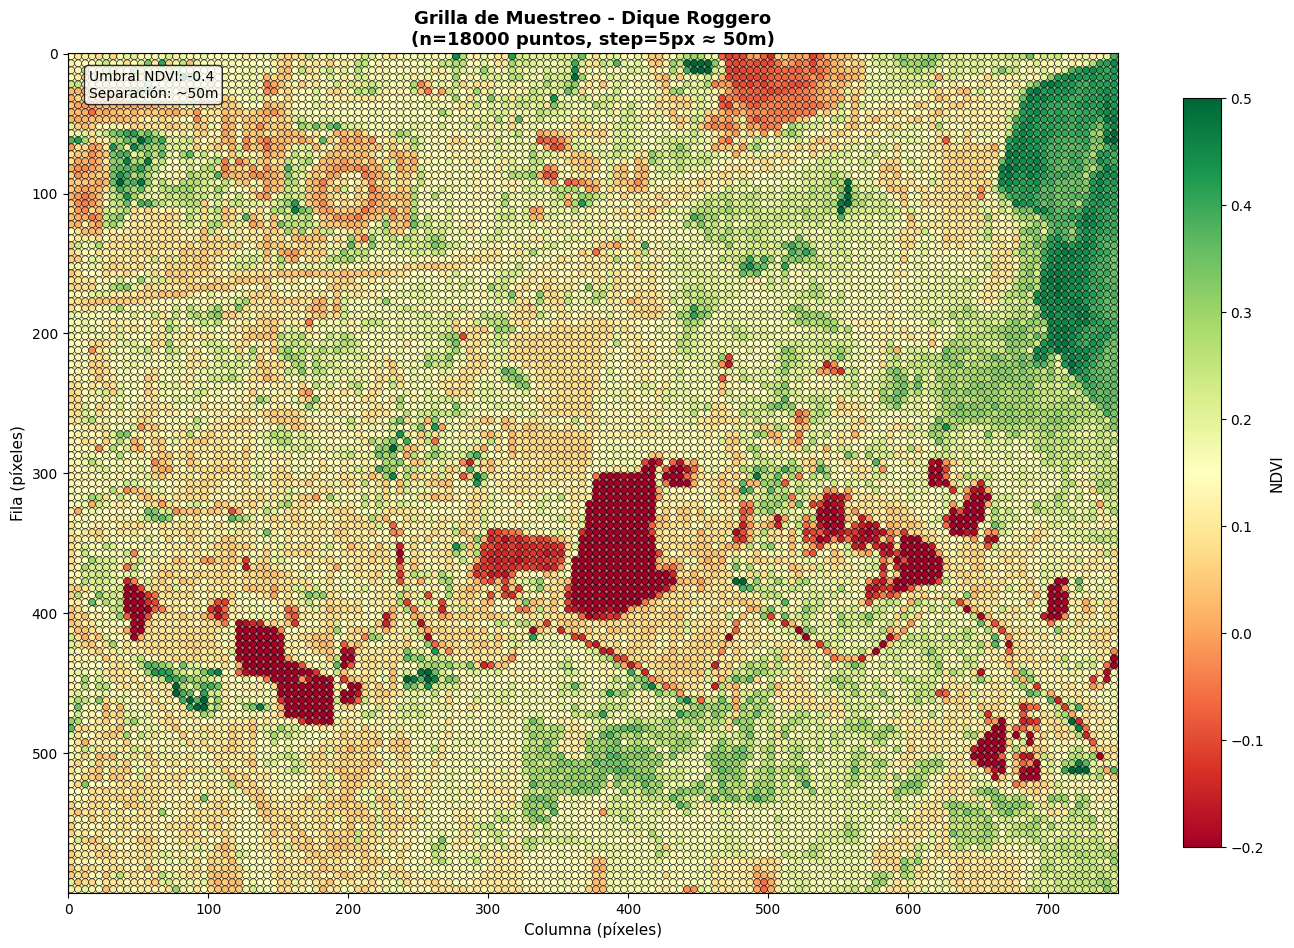

In [6]:
# Visualizar la grilla de muestreo con mejor contexto
fig, ax = plt.subplots(figsize=(14, 11))

# Plotear la imagen en coordenadas de píxeles
ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.5, alpha=0.6)

# Usar scatter con coordenadas de PÍXELES (col, row)
scatter = ax.scatter(points_gdf['col'], points_gdf['row'], 
                     c=points_gdf['ndvi'], cmap='RdYlGn',
                     s=25, edgecolor='black', linewidth=0.4,
                     vmin=-0.2, vmax=0.5)

# Añadir colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('NDVI', fontsize=11)

ax.set_title(f'Grilla de Muestreo - Dique Roggero\n(n={len(points_gdf)} puntos, step={step}px ≈ {step*10}m)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Columna (píxeles)', fontsize=11)
ax.set_ylabel('Fila (píxeles)', fontsize=11)

# Agregar información en el gráfico
info_text = f'Umbral NDVI: {ndvi_threshold}\nSeparación: ~{step*10}m'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10, 
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [7]:
# Crear matriz de pesos espaciales usando K-nearest neighbors
k_neighbors = 8  # Equivalente a ventana 3×3 en raster
W_ndvi = weights.KNN.from_dataframe(points_gdf, k=k_neighbors)
W_ndvi.transform = 'B'  # Sin estandarizar (binaria)

print("=" * 70)
print("MATRIZ DE PESOS ESPACIALES")
print("=" * 70)
print(f"Tipo: K-Nearest Neighbors (KNN)")
print(f"K: {k_neighbors} vecinos")
print(f"Número de ubicaciones: {W_ndvi.n}")
print(f"Promedio de vecinos: {W_ndvi.mean_neighbors:.2f}")
print("=" * 70)

MATRIZ DE PESOS ESPACIALES
Tipo: K-Nearest Neighbors (KNN)
K: 8 vecinos
Número de ubicaciones: 18000
Promedio de vecinos: 8.00


In [ ]:
# Calcular G_i* para NDVI
# Normalizar NDVI a rango [0,1] para cumplir con requisito de positividad
ndvi_normalized = (points_gdf['ndvi'].values - points_gdf['ndvi'].min()) + 0.01
y_ndvi = ndvi_normalized

print("\nCalculando estadístico Getis-Ord G_i*...")
# Calcular estadístico
g_local_ndvi = esda.G_Local(y_ndvi, W_ndvi, star=True, permutations= 999)

# Agregar resultados al GeoDataFrame
points_gdf['G_ndvi_Zs'] = g_local_ndvi.Zs
points_gdf['G_ndvi_p'] = g_local_ndvi.p_sim

# Clasificar clusters con múltiples niveles de significancia
alpha = 0.05
z_crit = 1.96
points_gdf['ndvi_cluster'] = 'No Significativo'
points_gdf.loc[(points_gdf['G_ndvi_Zs'] > z_crit) & (points_gdf['G_ndvi_p'] < alpha), 'ndvi_cluster'] = 'Hotspot Vegetación'
points_gdf.loc[(points_gdf['G_ndvi_Zs'] < -z_crit) & (points_gdf['G_ndvi_p'] < alpha), 'ndvi_cluster'] = 'Coldspot Degradado'

# Estadísticas detalladas
n_hot = (points_gdf['ndvi_cluster'] == 'Hotspot Vegetación').sum()
n_cold = (points_gdf['ndvi_cluster'] == 'Coldspot Degradado').sum()
n_ns = (points_gdf['ndvi_cluster'] == 'No Significativo').sum()

print("\n" + "=" * 70)
print("RESULTADOS DEL ANÁLISIS G_i*")
print("=" * 70)
print(f"\nClusters NDVI identificados (α={alpha}, |Z| > {z_crit}):")
print(f"  ✓ Hotspots (vegetación densa):  {n_hot:4d} ({n_hot/len(points_gdf)*100:5.1f}%)")
print(f"  ✓ Coldspots (degradado/urbano): {n_cold:4d} ({n_cold/len(points_gdf)*100:5.1f}%)")
print(f"  ○ No significativos:             {n_ns:4d} ({n_ns/len(points_gdf)*100:5.1f}%)")

print(f"\nEstadísticas de Z-scores:")
print(f"  Media:    {points_gdf['G_ndvi_Zs'].mean():7.3f}")
print(f"  Mediana:  {points_gdf['G_ndvi_Zs'].median():7.3f}")
print(f"  Desv.Std: {points_gdf['G_ndvi_Zs'].std():7.3f}")
print(f"  Rango:    [{points_gdf['G_ndvi_Zs'].min():6.3f}, {points_gdf['G_ndvi_Zs'].max():6.3f}]")

# NDVI promedio por tipo de cluster
print(f"\nNDVI promedio por tipo de cluster:")
for cluster_type in ['Hotspot Vegetación', 'No Significativo', 'Coldspot Degradado']:
    subset = points_gdf[points_gdf['ndvi_cluster'] == cluster_type]
    if len(subset) > 0:
        print(f"  {cluster_type:25s}: {subset['ndvi'].mean():.3f} (n={len(subset)})")

print("=" * 70)


Calculando estadístico Getis-Ord G_i*...

RESULTADOS DEL ANÁLISIS G_i*

Clusters NDVI identificados (α=0.05, |Z| > 1.96):
  ✓ Hotspots (vegetación densa):   460 (  2.6%)
  ✓ Coldspots (degradado/urbano):  552 (  3.1%)
  ○ No significativos:             16988 ( 94.4%)

Estadísticas de Z-scores:
  Media:      0.000
  Mediana:    0.006
  Desv.Std:   0.849
  Rango:    [-3.921,  2.730]

NDVI promedio por tipo de cluster:
  Hotspot Vegetación       : 0.427 (n=460)
  No Significativo         : 0.150 (n=16988)
  Coldspot Degradado       : -0.223 (n=552)


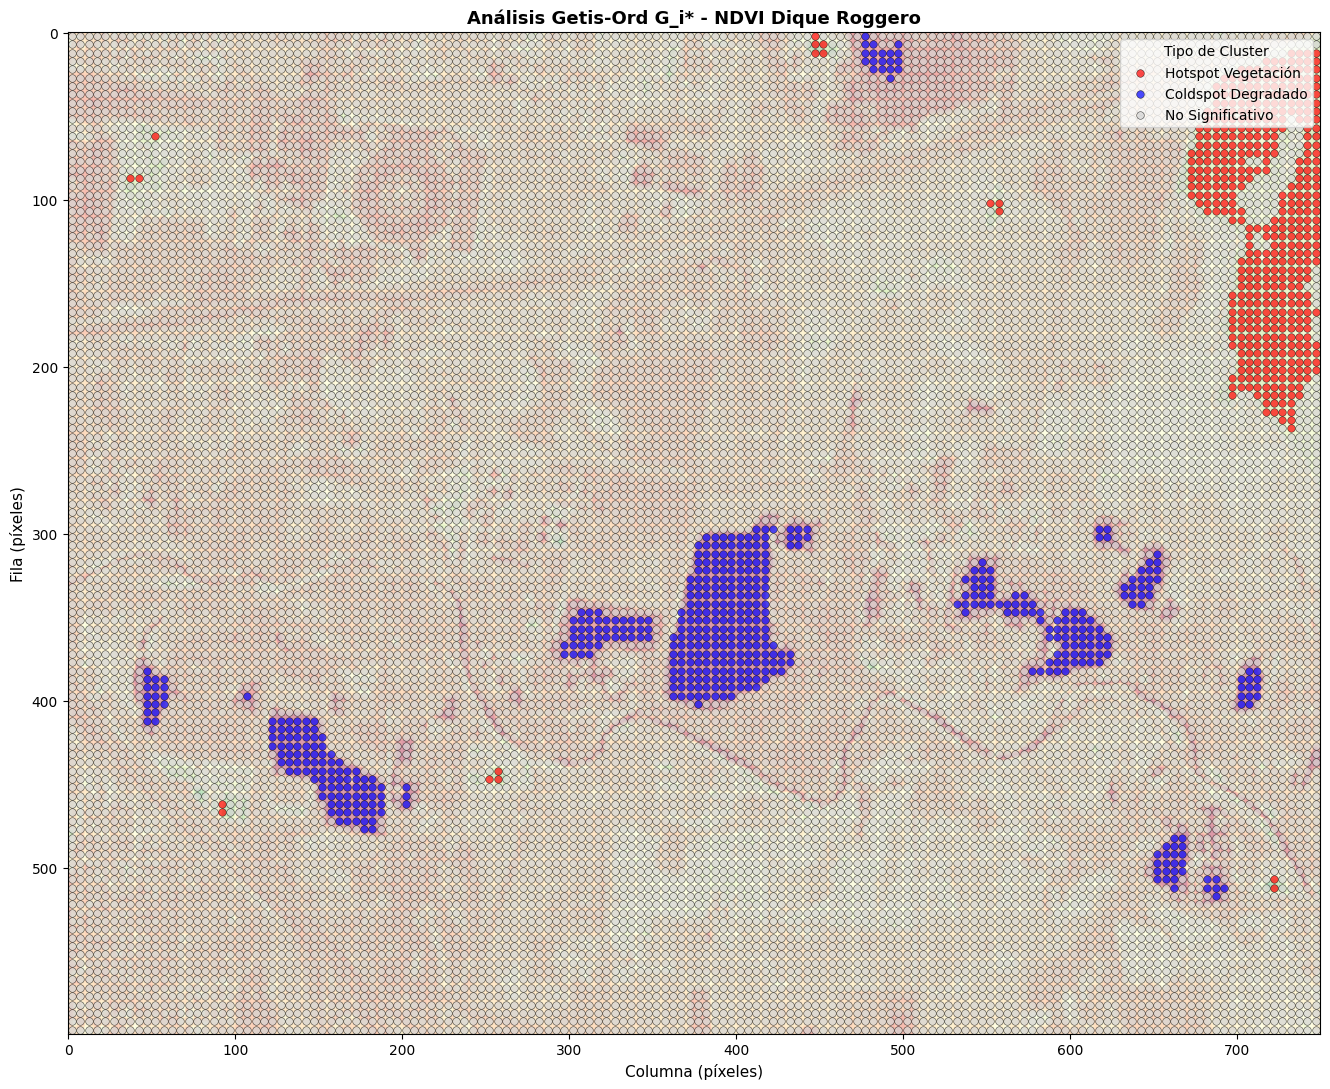

In [9]:
# Visualizar resultados del análisis G_i*
fig, ax = plt.subplots(figsize=(14, 11))
cluster_colors = {
    'Hotspot Vegetación': 'red',
    'Coldspot Degradado': 'blue',
    'No Significativo': 'lightgrey'
}
for cluster_type, color in cluster_colors.items():
    subset = points_gdf[points_gdf['ndvi_cluster'] == cluster_type]
    ax.scatter(subset['col'], subset['row'], 
               c=color, label=cluster_type,
               s=30, edgecolor='black', linewidth=0.4, alpha=0.7)
ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8, alpha=0.4)
ax.set_title('Análisis Getis-Ord G_i* - NDVI Dique Roggero', fontsize=13, fontweight='bold')
ax.set_xlabel('Columna (píxeles)', fontsize=11)
ax.set_ylabel('Fila (píxeles)', fontsize=11)
ax.legend(title='Tipo de Cluster')
plt.tight_layout()

In [10]:
"C:\Users\USUARIO\Downloads\SPOT_20170806_PAN.tif"

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2354886946.py, line 1)